# Лабораторная работа №6

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import math
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_validate
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import (BaggingClassifier, BaggingRegressor,
                              RandomForestClassifier, RandomForestRegressor,
                              GradientBoostingClassifier, GradientBoostingRegressor,
                              AdaBoostClassifier, AdaBoostRegressor,
                              StackingClassifier, StackingRegressor)
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             mean_squared_error, mean_absolute_error, r2_score, confusion_matrix, RocCurveDisplay, classification_report, mean_absolute_percentage_error)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor

from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, f_regression, RFE
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE, Isomap
from sklearn.metrics import f1_score, accuracy_score, precision_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
import umap

import optuna

RNG_SEED = 42
np.random.seed(RNG_SEED)

### Загрузка датасетов

In [3]:
df_wine = pd.read_csv('../data/final_data_wine.csv', index_col=0)
df_wine

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11,34,0.99780,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25,67,0.99680,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15,54,0.99700,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17,60,0.99800,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11,34,0.99780,3.51,0.56,9.4,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24,92,0.99114,3.27,0.50,11.2,6,0
4894,6.6,0.32,0.36,8.0,0.047,57,168,0.99490,3.15,0.46,9.6,5,0
4895,6.5,0.24,0.19,1.2,0.041,30,111,0.99254,2.99,0.46,9.4,6,0
4896,5.5,0.29,0.30,1.1,0.022,20,110,0.98869,3.34,0.38,12.8,7,0


In [4]:
df_wine.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6021 entries, 0 to 4897
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6021 non-null   float64
 1   volatile acidity      6021 non-null   float64
 2   citric acid           6021 non-null   float64
 3   residual sugar        6021 non-null   float64
 4   chlorides             6021 non-null   float64
 5   free sulfur dioxide   6021 non-null   int64  
 6   total sulfur dioxide  6021 non-null   int64  
 7   density               6021 non-null   float64
 8   pH                    6021 non-null   float64
 9   sulphates             6021 non-null   float64
 10  alcohol               6021 non-null   float64
 11  quality               6021 non-null   int64  
 12  type                  6021 non-null   int64  
dtypes: float64(9), int64(4)
memory usage: 658.5 KB


In [5]:
df_diamonds = pd.read_csv("../data/final_data_diamonds.csv", index_col=0)
df_diamonds

,carat,cut,color,clarity,depth,table,price,x,y,z
0,-1.199341,4,5,1,-0.176255,-1.096824,326,-1.587838,-1.573373,-1.593630
1,-1.241582,3,5,2,-1.381334,1.591635,326,-1.641325,-1.699002,-1.766179
2,-1.199341,1,5,4,-3.437056,3.383941,327,-1.498691,-1.492612,-1.766179
3,-1.072620,3,1,3,0.461729,0.247406,334,-1.364972,-1.349036,-1.306050
4,-1.030379,1,0,1,1.099711,0.247406,335,-1.240166,-1.241354,-1.133502
...,...,...,...,...,...,...,...,...,...,...
53935,-0.164447,4,6,2,-0.672465,-0.200671,2757,0.016798,0.023909,-0.055076
53936,-0.164447,1,6,2,0.957936,-1.096824,2757,-0.036690,0.014935,0.103093
53937,-0.206688,2,6,2,0.745276,1.143559,2757,-0.063434,-0.047880,0.031198
53938,0.131237,3,2,1,-0.530690,0.247406,2757,0.373383,0.346954,0.290021


In [6]:
df_diamonds.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  int64  
 2   color    53940 non-null  int64  
 3   clarity  53940 non-null  int64  
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(4)
memory usage: 4.5 MB


**Разделение выборок**

In [7]:
X_cls = df_wine.drop(columns=['quality', 'type'])
y_cls = df_wine['type']

X_reg = df_diamonds.drop(columns=['price'])
y_reg = df_diamonds['price']

print(f"Train sizes: cls={X_cls.shape}, reg={X_reg.shape}")

Train sizes: cls=(6021, 11), reg=(53940, 9)


## Решение задачи понижения размерности

In [8]:
result_cls = {}
result_reg = {}

In [9]:
vt_cls = VarianceThreshold(threshold=1)
vt_cls.fit(X_cls)
selected_vt_cls = X_cls.columns[vt_cls.get_support()]
print("Отобранные признаки (VarianceThreshold):", selected_vt_cls.tolist())

vt_reg = VarianceThreshold(threshold=1)
vt_reg.fit(X_reg)
selected_vt_reg = X_reg.columns[vt_reg.get_support()]
print("Отобранные признаки (VarianceThreshold):", selected_vt_reg.tolist())

result_cls["VarianceThreshold"] = vt_cls.transform(X_cls)
result_reg["VarianceThreshold"] = vt_reg.transform(X_reg)

Отобранные признаки (VarianceThreshold): ['fixed acidity', 'residual sugar', 'free sulfur dioxide', 'total sulfur dioxide', 'alcohol']
Отобранные признаки (VarianceThreshold): ['carat', 'cut', 'color', 'clarity', 'y', 'z']


Отобранные признаки (SelectKBest): ['volatile acidity', 'chlorides', 'total sulfur dioxide', 'sulphates']
Отобранные признаки (SelectKBest): ['carat', 'x', 'y', 'z']


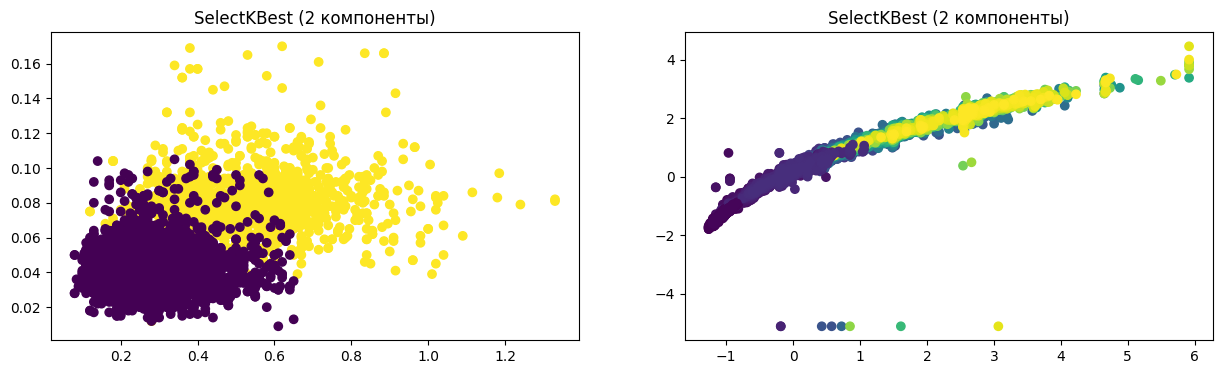

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15,4))
skb = SelectKBest(score_func=f_classif, k=4)

X_skb_cls = skb.fit_transform(X_cls, y_cls)
print("Отобранные признаки (SelectKBest):", X_cls.columns[skb.get_support()].tolist())
axes[0].scatter(X_skb_cls[:,0], X_skb_cls[:,1], c=y_cls, cmap='viridis')
axes[0].set_title('SelectKBest (2 компоненты)')

X_skb_reg = skb.fit_transform(X_reg, y_reg)
print("Отобранные признаки (SelectKBest):", X_reg.columns[skb.get_support()].tolist())
axes[1].scatter(X_skb_reg[:,0], X_skb_reg[:,1], c=y_reg, cmap='viridis')
axes[1].set_title('SelectKBest (2 компоненты)')

fig.show()


result_cls["SelectKBest"] = X_skb_cls
result_reg["SelectKBest"] = X_skb_reg

Отобранные признаки (RFE): ['volatile acidity', 'chlorides', 'pH', 'sulphates']
Отобранные признаки (RFE): ['carat', 'x', 'y', 'z']


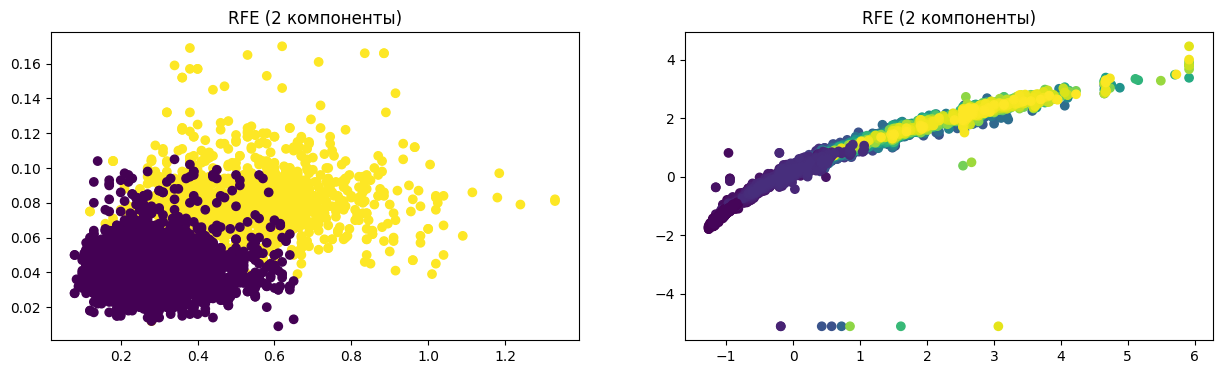

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15,4))
rfe = RFE(estimator=LogisticRegression(max_iter=1000, solver='lbfgs'), n_features_to_select=4)

X_rfe_cls = rfe.fit_transform(X_cls, y_cls)
print("Отобранные признаки (RFE):", X_cls.columns[rfe.support_].tolist())
axes[0].scatter(X_rfe_cls[:,0], X_rfe_cls[:,1], c=y_cls, cmap='viridis')
axes[0].set_title('RFE (2 компоненты)')

X_rfe_reg = skb.fit_transform(X_reg, y_reg)
print("Отобранные признаки (RFE):", X_reg.columns[skb.get_support()].tolist())
axes[1].scatter(X_rfe_reg[:,0], X_rfe_reg[:,1], c=y_reg, cmap='viridis')
axes[1].set_title('RFE (2 компоненты)')

fig.show()

result_cls["RFE"] = X_rfe_cls
result_reg["RFE"] = X_rfe_reg

PCA (Classification): Объяснённая дисперсия: [9.55125780e-01 3.93937391e-02 4.69128130e-03 4.69536565e-04]
PCA (Regression): Объяснённая дисперсия: [0.39526874 0.22826809 0.13393627 0.11422211]


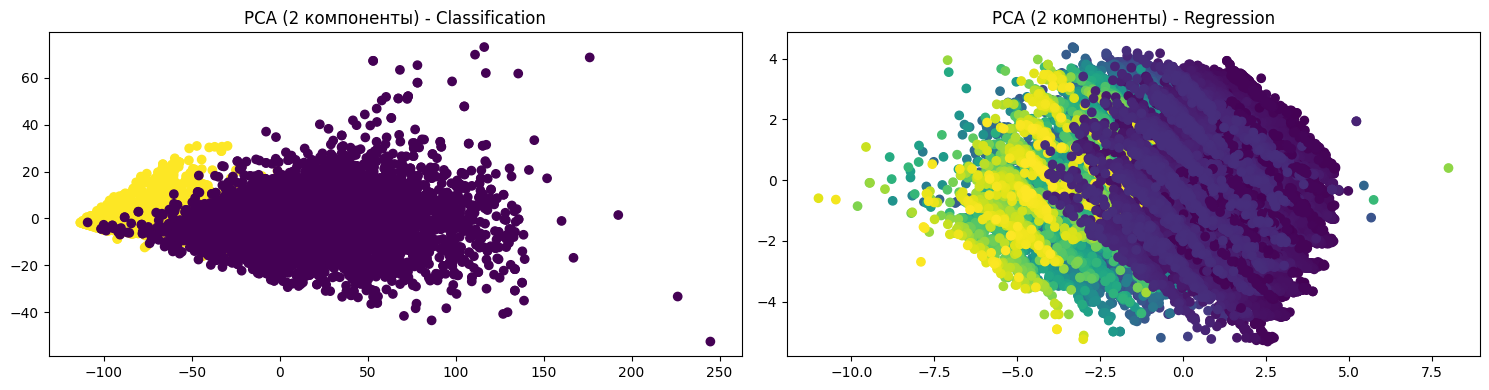

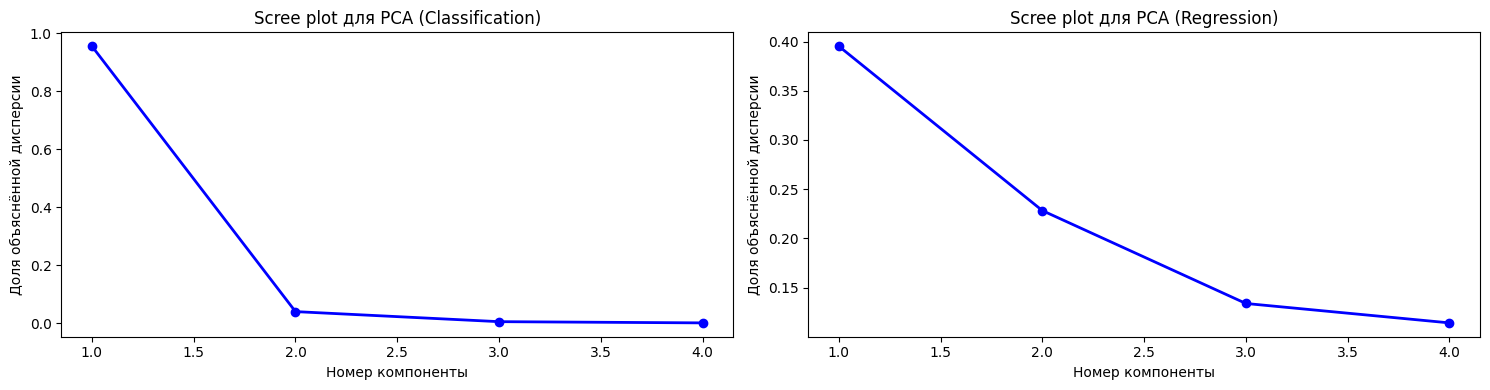

In [12]:
# 1. Создаем ОТДЕЛЬНЫЕ объекты PCA для классификации и регрессии
pca_cls = PCA(n_components=4)
pca_reg = PCA(n_components=4)

# 2. Обучаем и преобразуем данные
X_pca_cls = pca_cls.fit_transform(X_cls)
X_pca_reg = pca_reg.fit_transform(X_reg)

# Сохраняем преобразованные массивы в словари
result_cls["PCA"] = X_pca_cls
result_reg["PCA"] = X_pca_reg

# ==========================================
# 3. График рассеяния (Scatter plot)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

print(f"PCA (Classification): Объяснённая дисперсия: {pca_cls.explained_variance_ratio_}")
axes[0].scatter(X_pca_cls[:, 0], X_pca_cls[:, 1], c=y_cls, cmap='viridis')
axes[0].set_title('PCA (2 компоненты) - Classification')

print(f"PCA (Regression): Объяснённая дисперсия: {pca_reg.explained_variance_ratio_}")
axes[1].scatter(X_pca_reg[:, 0], X_pca_reg[:, 1], c=y_reg, cmap='viridis')
axes[1].set_title('PCA (2 компоненты) - Regression')

plt.tight_layout()
plt.show()

# ==========================================
# 4. График объяснённой дисперсии (Scree plot)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# ВАЖНО: берем explained_variance_ratio_ у объектов pca_cls и pca_reg, а не у массивов X_pca_*
axes[0].plot(range(1, len(pca_cls.explained_variance_ratio_) + 1), 
             pca_cls.explained_variance_ratio_, 'bo-', linewidth=2)
axes[0].set_title('Scree plot для PCA (Classification)')
axes[0].set_xlabel('Номер компоненты')
axes[0].set_ylabel('Доля объяснённой дисперсии')

axes[1].plot(range(1, len(pca_reg.explained_variance_ratio_) + 1), 
             pca_reg.explained_variance_ratio_, 'bo-', linewidth=2)
axes[1].set_title('Scree plot для PCA (Regression)')
axes[1].set_xlabel('Номер компоненты')
axes[1].set_ylabel('Доля объяснённой дисперсии')

plt.tight_layout()
plt.show()

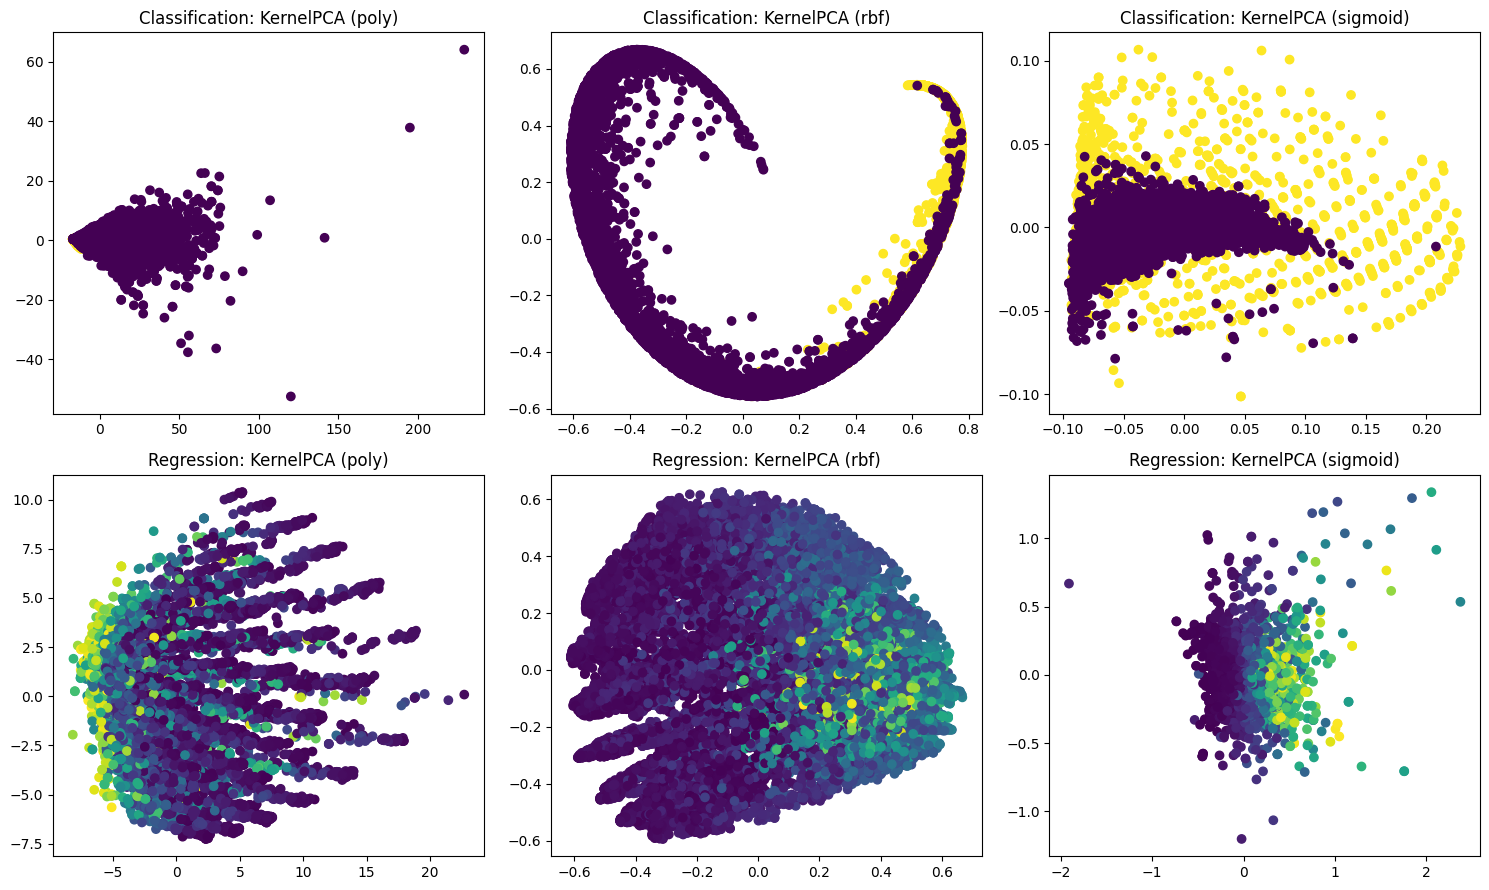

In [13]:
gamma_val_cls = 1 / (X_cls.shape[1] * np.var(X_cls).mean())
gamma_val_reg = 1 / (X_reg.shape[1] * np.var(X_reg).mean())

kernels = ['poly', 'rbf', 'sigmoid']
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for i, ker in enumerate(kernels):
    kpca = KernelPCA(n_components=4, kernel=ker, gamma=gamma_val_cls)
    X_kpca = kpca.fit_transform(X_cls)
    axes[0, i].scatter(X_kpca[:,0], X_kpca[:,1], c=y_cls, cmap='viridis')
    axes[0, i].set_title(f'Classification: KernelPCA ({ker})')
    result_cls[f"PCA {ker}"] = X_kpca

n_samples = 20000
X_reg_sub, y_reg_sub = resample(X_reg, y_reg, 
                                n_samples=n_samples, random_state=42 )

for i, ker in enumerate(kernels):
    kpca = KernelPCA(n_components=4, kernel=ker, gamma=gamma_val_reg)
    X_kpca = kpca.fit_transform(X_reg_sub)
    axes[1, i].scatter(X_kpca[:,0], X_kpca[:,1], c=y_reg_sub, cmap='viridis')
    axes[1, i].set_title(f'Regression: KernelPCA ({ker})')
    result_reg[f"PCA {ker}"] = X_kpca

plt.tight_layout()
plt.show()


result_reg["PCA"] = X_pca_reg

  File "c:\Users\danii\Desktop\git\master\mlbd\venv\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "C:\Users\danii\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Users\danii\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\danii\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 1456, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


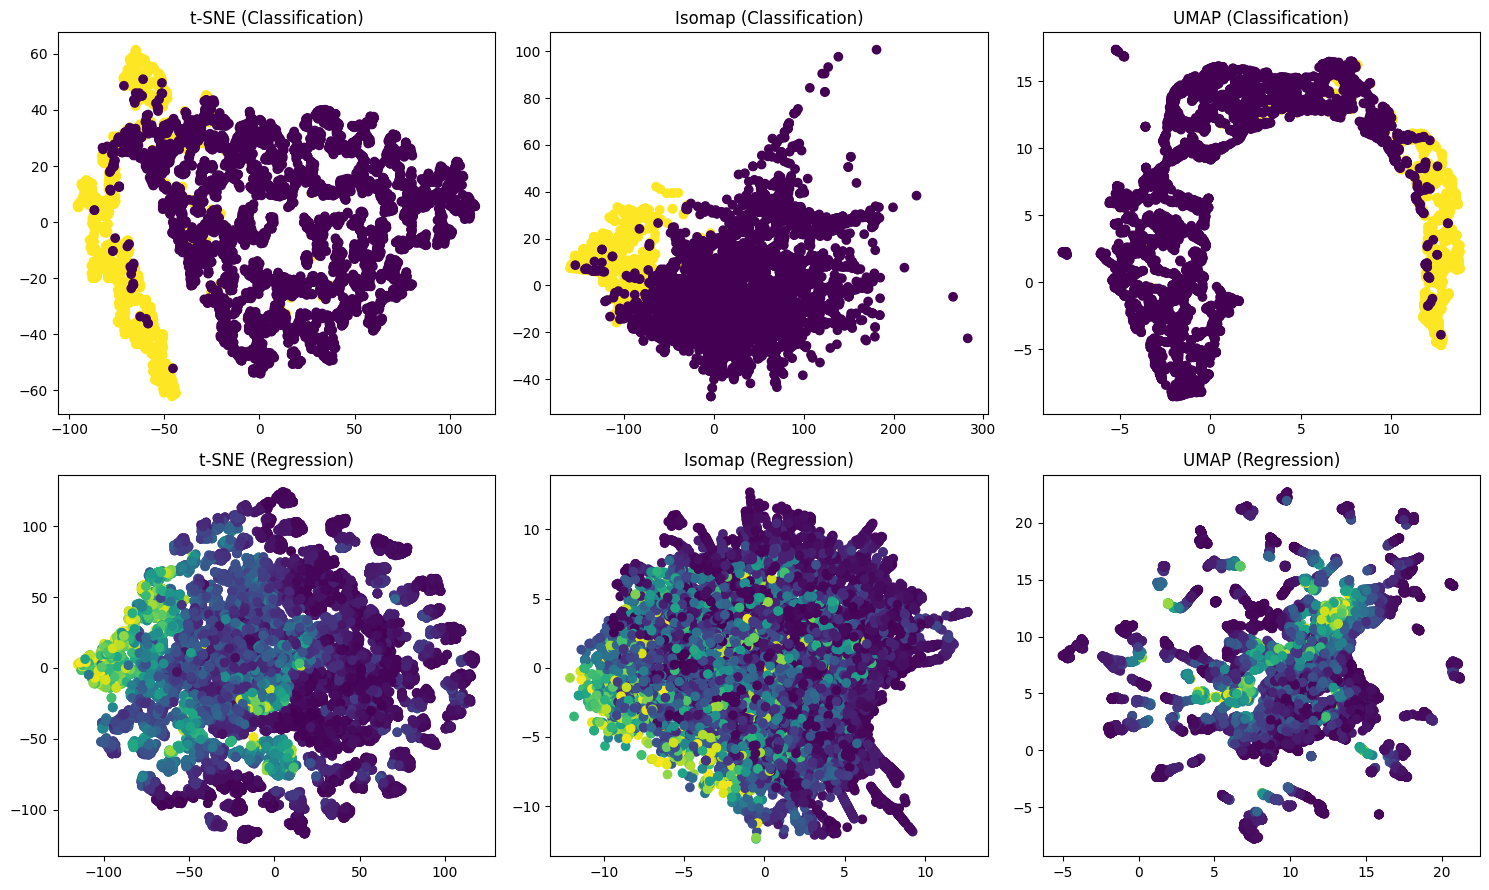

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15,9))

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_cls)
axes[0, 0].scatter(X_tsne[:,0], X_tsne[:,1], c=y_cls, cmap='viridis')
axes[0, 0].set_title('t-SNE (Classification)')
result_cls["TSNE"] = X_tsne

isomap = Isomap(n_components=2, n_neighbors=5)
X_isomap = isomap.fit_transform(X_cls)
axes[0, 1].scatter(X_isomap[:,0], X_isomap[:,1], c=y_cls, cmap='viridis')
axes[0, 1].set_title('Isomap (Classification)')
result_cls["Isomap"] = X_isomap

umap_reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_reducer.fit_transform(X_cls)
axes[0, 2].scatter(X_umap[:,0], X_umap[:,1], c=y_cls, cmap='viridis')
axes[0, 2].set_title('UMAP (Classification)')
result_cls["UMAP"] = X_umap

n_samples = 20000
X_reg_sub, y_reg_sub = resample(X_reg, y_reg, 
                                n_samples=n_samples, random_state=42)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_reg_sub)
axes[1, 0].scatter(X_tsne[:,0], X_tsne[:,1], c=y_reg_sub, cmap='viridis')
axes[1, 0].set_title('t-SNE (Regression)')
result_reg["TSNE"] = X_tsne

isomap = Isomap(n_components=2, n_neighbors=5)
X_isomap = isomap.fit_transform(X_reg_sub)
axes[1, 1].scatter(X_isomap[:,0], X_isomap[:,1], c=y_reg_sub, cmap='viridis')
axes[1, 1].set_title('Isomap (Regression)')
result_reg["Isomap"] = X_isomap

umap_reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_reducer.fit_transform(X_reg_sub)
axes[1, 2].scatter(X_umap[:,0], X_umap[:,1], c=y_reg_sub, cmap='viridis')
axes[1, 2].set_title('UMAP (Regression)')
result_reg["UMAP"] = X_umap

plt.tight_layout()
plt.show()

In [ ]:
print(result_cls)
print(result_reg)

{'VarianceThreshold': array([[ 2.2834747 , -2.2794418 , -1.13313767,  1.0924363 ,  1.8081309 ],
       [ 3.4059043 , -2.2794418 , -0.32220642,  0.7516124 , -0.12511182],
       [ 2.6576178 , -1.9886491 , -0.90144303,  0.819769  ,  0.2490639 ],
       ...,
       [-0.58495635, -0.89817643, -0.03258812, -0.70031714, -1.4347283 ],
       [-0.2731704 , -0.09849638, -0.61182472, -2.0125003 ,  0.74796486],
       [-0.77202797,  0.4830889 , -0.4959774 , -1.767116  ,  0.2490639 ]]), 'SelectKBest': array([[ 0.16434315,  2.2834747 ,  1.2380011 , -1.46793396],
       [ 0.47759965,  3.4059043 ,  2.34458   , -0.87641691],
       [ 0.47759965,  2.6576178 ,  2.042786  , -1.10943878],
       ...,
       [-0.5404839 , -0.58495635, -0.5224649 , -0.0877275 ],
       [-1.323625  , -0.2731704 , -1.4781466 , -0.10565226],
       [-0.93205446, -0.77202797, -1.5787446 , -0.32074937]]), 'RFE': array([[-0.74995196,  1.2380011 , -1.46793396,  1.0924363 ],
       [-0.6012548 ,  2.34458   , -0.87641691,  0.7516124

## Обучение моделей в пространстве низкой размерности
В качестве моделей выберем:
- **Классификация**: `RandomForestClassifier` (устойчив к шуму, хорошо работает с PCA)
- **Регрессия**: `Ridge` (линейная регуляризация, хорошо сочетается с PCA)

In [16]:
def calculate_metrics_cls(y_true, y_pred):
    return {
        'F1': f1_score(y_true, y_pred),
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred)
    }

def calculate_metrics_reg(y_true, y_pred):
    return {
        'R2': r2_score(y_true, y_pred),
        'MSE': mean_squared_error(y_true, y_pred),
        'RMSE': math.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'MAPE': mean_absolute_percentage_error(y_true, y_pred)
    }

def fmt_val(val, metric_name):
    prec = 2 if metric_name == 'F1' or metric_name == 'R2'else 4
    return f"{val:.{prec}f}"


In [17]:
holdout_cls = []
fixed_clf = RandomForestClassifier(n_estimators=100, random_state=42)
metrics_cls = ['F1', 'Accuracy', 'Precision', 'Recall']

for method_name, X in result_cls.items():
    X_tr, X_te, y_tr, y_te = train_test_split(X, y_cls, test_size=0.2, random_state=42)
    
    pipe = Pipeline([('scaler', StandardScaler()), ('model', fixed_clf)])
    pipe.fit(X_tr, y_tr)
    
    train_m = calculate_metrics_cls(y_tr, pipe.predict(X_tr))
    test_m = calculate_metrics_cls(y_te, pipe.predict(X_te))
    
    row = {'Method': method_name}
    for m in metrics_cls:
        row[('Train Data', m)] = fmt_val(train_m[m], m)
        row[('Test Data', m)] = fmt_val(test_m[m], m)
    holdout_cls.append(row)

cols_cls = pd.MultiIndex.from_product([['Train Data', 'Test Data'], metrics_cls])
df_cls = pd.DataFrame(holdout_cls).set_index('Method').reindex(columns=cols_cls)
display(df_cls.style.set_caption("Классификация: модель (RF)"))


### Вывод по классификации

Все модели понижения размерности очень хорошо отработали, почти так же, как и без этих методов. Только `VarianceThreshold` показал результаты чуть хуже остальных, но все равно на приемлимом уровне.

Все методы понижения размерности выдают тот же очень выссокий результат, что и без применения этих методов

In [18]:
holdout_reg = []
fixed_reg = Ridge(alpha=1.0)
metrics_reg = ['R2', 'MSE', 'RMSE', 'MAE', 'MAPE']

for method_name, X_2d in result_reg.items():
    if len(X_2d) != len(y_reg):
        y_curr = y_reg.iloc[:len(X_2d)] if hasattr(y_reg, 'iloc') else y_reg[:len(X_2d)]
    else:
        y_curr = y_reg
        
    X_tr, X_te, y_tr, y_te = train_test_split(X_2d, y_curr, test_size=0.2, random_state=42)
    
    pipe = Pipeline([('scaler', StandardScaler()), ('model', fixed_reg)])
    pipe.fit(X_tr, y_tr)
    
    train_m = calculate_metrics_reg(y_tr, pipe.predict(X_tr))
    test_m = calculate_metrics_reg(y_te, pipe.predict(X_te))
    
    row = {'Method': method_name}
    for m in metrics_reg:
        row[('Train Data', m)] = fmt_val(train_m[m], m)
        row[('Test Data', m)] = fmt_val(test_m[m], m)
    holdout_reg.append(row)

cols_reg = pd.MultiIndex.from_product([['Train Data', 'Test Data'], metrics_reg])
df_reg = pd.DataFrame(holdout_reg).set_index('Method').reindex(columns=cols_reg)
display(df_reg.style.set_caption("Регрессия: модель (Ridge)"))

### Выводы по регрессии

PCA с ядарми и нелинейные методы не справились с задачей, возможно ввиду уменьшения датасетов в 3 раз на обучении, чтобы вписать в рамки вычислительных возможностей.

Если говорить об удачных экспериментах, `RFE` и `SelectKBest` показал лучший результат, почти идентчный обучению на исходжных данных без применения методов понижения размерности


In [19]:
from my_pca import MyPCA

def compare_pca_implementations(X: np.ndarray, n_components: int = 2) -> dict:
    from sklearn.decomposition import PCA as SklearnPCA
    
    my_pca = MyPCA(n_components=n_components)
    X_my = my_pca.fit_transform(X)
    
    sklearn_pca = SklearnPCA(n_components=n_components)
    X_sklearn = sklearn_pca.fit_transform(X)
    
    results = {
        'my_pca': {
            'transformed': X_my,
            'components': my_pca.components_,
            'explained_variance': my_pca.explained_variance_,
            'explained_variance_ratio': my_pca.explained_variance_ratio_
        },
        'sklearn_pca': {
            'transformed': X_sklearn,
            'components': sklearn_pca.components_,
            'explained_variance': sklearn_pca.explained_variance_,
            'explained_variance_ratio': sklearn_pca.explained_variance_ratio_
        },
        'comparison': {
            'transform_diff': np.abs(X_my - X_sklearn).mean(),
            'components_diff': np.abs(my_pca.components_ - sklearn_pca.components_).mean(),
            'variance_diff': np.abs(my_pca.explained_variance_ - sklearn_pca.explained_variance_).mean(),
            'variance_ratio_diff': np.abs(my_pca.explained_variance_ratio_ - sklearn_pca.explained_variance_ratio_).mean()
        }
    }
    
    return results

## Собственный PCA

In [20]:
my_pca = MyPCA(n_components=4)
X_my = my_pca.fit_transform(X_reg)

sk_pca = PCA(n_components=4)
X_sk = sk_pca.fit_transform(X_reg)

print("МЕТРИКИ МОЕЙ РЕАЛИЗАЦИИ PCA (n_components=4)")
print(f"Объяснённая дисперсия:        {my_pca.explained_variance_}")
print(f"Доли объяснённой дисперсии:   {my_pca.explained_variance_ratio_}")
print(f"Суммарная объяснённая дисперсия: {np.sum(my_pca.explained_variance_ratio_):.4f} ({np.sum(my_pca.explained_variance_ratio_)*100:.2f}%)")
print(f"Размер преобразованных данных: {X_my.shape}")
print(f"Первые 5 строк преобразованных данных:\n{X_my[:5]}")

print()

print("МЕТРИКИ SKLEARN РЕАЛИЗАЦИИ PCA (n_components=4)")
print(f"Объяснённая дисперсия:        {sk_pca.explained_variance_}")
print(f"Доли объяснённой дисперсии:   {sk_pca.explained_variance_ratio_}")
print(f"Суммарная объяснённая дисперсия: {np.sum(sk_pca.explained_variance_ratio_):.4f} ({np.sum(sk_pca.explained_variance_ratio_)*100:.2f}%)")
print(f"Размер преобразованных данных: {X_my.shape}")
print(f"Первые 5 строк преобразованных данных:\n{X_my[:5]}")

МЕТРИКИ МОЕЙ РЕАЛИЗАЦИИ PCA (n_components=4)
Объяснённая дисперсия:        [5.08067429 2.93409438 1.72157955 1.46817921]
Доли объяснённой дисперсии:   [0.39526874 0.22826809 0.13393627 0.11422211]
Суммарная объяснённая дисперсия: 0.8717 (87.17%)
Размер преобразованных данных: (53940, 4)
Первые 5 строк преобразованных данных:
[[ 2.34048275 -2.21371358 -1.74140941  2.02547383]
 [ 2.53022659 -2.01396254 -1.50761331 -0.80509785]
 [ 2.83918074 -1.28911421 -0.52017352 -4.2125941 ]
 [ 1.20395478  1.90441088 -2.6729337   0.11588777]
 [-0.45462412  1.32025772 -4.85908978 -0.51896217]]

МЕТРИКИ SKLEARN РЕАЛИЗАЦИИ PCA (n_components=4)
Объяснённая дисперсия:        [5.08067429 2.93409438 1.72157955 1.46817921]
Доли объяснённой дисперсии:   [0.39526874 0.22826809 0.13393627 0.11422211]
Суммарная объяснённая дисперсия: 0.8717 (87.17%)
Размер преобразованных данных: (53940, 4)
Первые 5 строк преобразованных данных:
[[ 2.34048275 -2.21371358 -1.74140941  2.02547383]
 [ 2.53022659 -2.01396254 -1.507613

In [21]:
my_pca = MyPCA(n_components=4)
X_my = my_pca.fit_transform(X_cls)

sk_pca = PCA(n_components=4)
X_sk = sk_pca.fit_transform(X_cls)

print("МЕТРИКИ МОЕЙ РЕАЛИЗАЦИИ PCA (n_components=4)")
print(f"Объяснённая дисперсия:        {my_pca.explained_variance_}")
print(f"Доли объяснённой дисперсии:   {my_pca.explained_variance_ratio_}")
print(f"Суммарная объяснённая дисперсия: {np.sum(my_pca.explained_variance_ratio_):.4f} ({np.sum(my_pca.explained_variance_ratio_)*100:.2f}%)")
print(f"Размер преобразованных данных: {X_my.shape}")
print(f"Первые 5 строк преобразованных данных:\n{X_my[:5]}")

print()

print("МЕТРИКИ SKLEARN РЕАЛИЗАЦИИ PCA (n_components=4)")
print(f"Объяснённая дисперсия:        {sk_pca.explained_variance_}")
print(f"Доли объяснённой дисперсии:   {sk_pca.explained_variance_ratio_}")
print(f"Суммарная объяснённая дисперсия: {np.sum(sk_pca.explained_variance_ratio_):.4f} ({np.sum(sk_pca.explained_variance_ratio_)*100:.2f}%)")
print(f"Размер преобразованных данных: {X_my.shape}")
print(f"Первые 5 строк преобразованных данных:\n{X_my[:5]}")

МЕТРИКИ МОЕЙ РЕАЛИЗАЦИИ PCA (n_components=4)
Объяснённая дисперсия:        [3.28939949e+03 1.35669823e+02 1.61565090e+01 1.61705753e+00]
Доли объяснённой дисперсии:   [9.55125780e-01 3.93937391e-02 4.69128130e-03 4.69536565e-04]
Суммарная объяснённая дисперсия: 0.9997 (99.97%)
Размер преобразованных данных: (6021, 4)
Первые 5 строк преобразованных данных:
[[84.20123177 -0.38745761 -0.21738703  0.44901074]
 [48.89013095  5.70606485  0.799467    0.8210574 ]
 [63.82347551 -1.05945934  0.26978102  0.68809382]
 [57.57345182 -0.51489334  0.87557305  3.65385424]
 [84.20123177 -0.38745761 -0.21738703  0.44901074]]

МЕТРИКИ SKLEARN РЕАЛИЗАЦИИ PCA (n_components=4)
Объяснённая дисперсия:        [3.28939949e+03 1.35669823e+02 1.61565090e+01 1.61705753e+00]
Доли объяснённой дисперсии:   [9.55125780e-01 3.93937391e-02 4.69128130e-03 4.69536565e-04]
Суммарная объяснённая дисперсия: 0.9997 (99.97%)
Размер преобразованных данных: (6021, 4)
Первые 5 строк преобразованных данных:
[[84.20123177 -0.3874576

**Методы работают полностью аналогично, абсолютно не отличаясь**